In [29]:
from math import sqrt
import torch as th
import torch.nn as nn
from torch.nn.functional import softmax

def attentionSDP(queries, keys, values, mask=None):
    """scaled dot-product attention
    """
    
    weights = queries.matmul(keys.transpose(-2, -1))/sqrt(len(keys))

    if mask is not None:
        weights = weights.masked_fill(mask == 0, -1e9)

    return softmax(weights).matmul(values), weights

def attentionSDP_oneline(queries, keys, values):
    return softmax(queries.matmul(keys.transpose(-2, -1))/sqrt(len(keys))).matmul(values)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // num_heads

        self.q_linear = nn.Linear(self.d_model, self.d_model)
        self.k_linear = nn.Linear(self.d_model, self.d_model)
        self.v_linear = nn.Linear(self.d_model, self.d_model)
        self.out_linear = nn.Linear(self.d_model, self.d_model)

    def forward(self, queries, keys, values, mask=None):
        queries = self.unfold(self.q_linear(queries))
        keys = self.unfold(self.k_linear(keys))
        values = self.unfold(self.v_linear(values))

        values, _ = attentionSDP(queries, keys, values, mask=mask)

        return self.out_linear(self.fold(values))

    def unfold(self, t):
        """tensor t starts out with shape [batch_size, n_samples, d_model],
        ends up with [batch_size, n_heads, n_samples, d_k]
        """
        batch_size, n_samples, _ = t.shape
        return t.view(batch_size, n_samples, self.n_heads, self.d_k).transpose(1, 2)

    def fold(self, t):
        """tensor t starts out with shape [batch_size, n_heads, n_samples, d_k],
        ends up with [batch_size, n_samples, d_model]
        """
        batch_size, _, n_samples, _ = t.shape
        return t.transpose(2, 1).view(batch_size, n_samples, self.d_model)

In [2]:
import torch
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target


In [4]:
X.shape

(178, 13)

Using cpu device
Iteration t =   99  loss(t)/loss(0) =   0.008389  a =   0.520758  b =  -0.073076  c =  -0.089950  d =   0.038928
Iteration t =  199  loss(t)/loss(0) =   0.005650  a =   0.438089  b =   0.100639  c =  -0.075578  d =   0.014219
Iteration t =  299  loss(t)/loss(0) =   0.003815  a =   0.368530  b =   0.241899  c =  -0.063578  d =  -0.005874
Iteration t =  399  loss(t)/loss(0) =   0.002585  a =   0.310016  b =   0.356768  c =  -0.053483  d =  -0.022214
Iteration t =  499  loss(t)/loss(0) =   0.001759  a =   0.260792  b =   0.450176  c =  -0.044991  d =  -0.035500
Iteration t =  599  loss(t)/loss(0) =   0.001205  a =   0.219384  b =   0.526133  c =  -0.037847  d =  -0.046304
Iteration t =  699  loss(t)/loss(0) =   0.000833  a =   0.184551  b =   0.587900  c =  -0.031838  d =  -0.055090
Iteration t =  799  loss(t)/loss(0) =   0.000582  a =   0.155248  b =   0.638126  c =  -0.026783  d =  -0.062234
Iteration t =  899  loss(t)/loss(0) =   0.000414  a =   0.130598  b =   0.67897

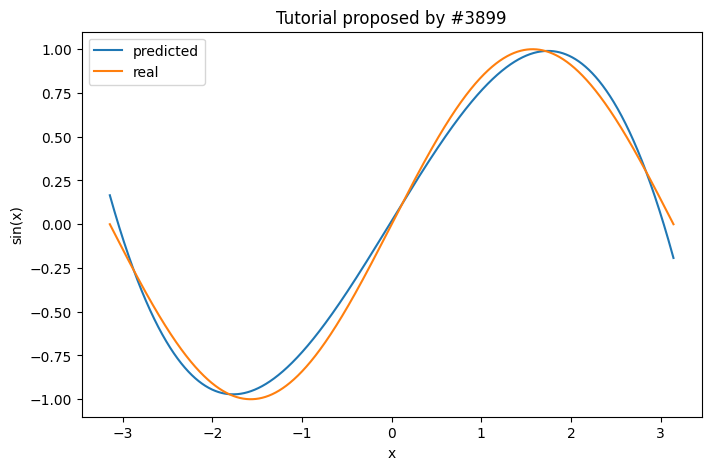

In [89]:
r"""
PyTorch: Tensors and autograd
-------------------------------

A third order polynomial, trained to predict :math:`y=\sin(x)` from :math:`-\pi`
to :math:`\pi` by minimizing squared Euclidean distance.

This implementation computes the forward pass using operations on PyTorch
Tensors, and uses PyTorch autograd to compute gradients.


A PyTorch Tensor represents a node in a computational graph. If ``x`` is a
Tensor with ``x.requires_grad=True``, then after backpropagating from a scalar
``loss``, ``x.grad`` is another Tensor storing the gradient of that scalar loss
with respect to ``x``.
"""

import torch

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-torch.pi, torch.pi, 2000, dtype=dtype)
y = torch.sin(x)

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_pred - y).pow(2).sum()

    # Calculate initial loss, so we can report loss relative to it
    if t==0:
        initial_loss=loss.item()

    if t % 100 == 99:
        print(f'Iteration t = {t:4d}  loss(t)/loss(0) = {round(loss.item()/initial_loss, 6):10.6f}  a = {a.item():10.6f}  b = {b.item():10.6f}  c = {c.item():10.6f}  d = {d.item():10.6f}')

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

import matplotlib.pyplot as plt

def fit(x):
    return a.item() + b.item() * x + c.item() * x**2 + d.item() * x**3 # + e.item() * x**4 + f.item() * x**5

y_pred = [fit(_x) for _x in x]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y_pred, label="predicted")
ax.plot(x, y, label="real")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("Tutorial proposed by #3899")
ax.legend()
plt.show()

Using cpu device
Iteration t =   99  loss(t)/loss(0) =   0.012074  a =   0.768266  b =   0.199385  c =   1.098761  d =   1.334310
Iteration t =  199  loss(t)/loss(0) =   0.008335  a =   0.845846  b =   0.287817  c =   0.951123  d =   1.283231
Iteration t =  299  loss(t)/loss(0) =   0.006284  a =   0.887019  b =   0.339277  c =   0.838207  d =   1.215666
Iteration t =  399  loss(t)/loss(0) =   0.004968  a =   0.916811  b =   0.382549  c =   0.756021  d =   1.149365
Iteration t =  499  loss(t)/loss(0) =   0.004068  a =   0.938479  b =   0.422278  c =   0.696242  d =   1.086847
Iteration t =  599  loss(t)/loss(0) =   0.003412  a =   0.954240  b =   0.459332  c =   0.652760  d =   1.028276
Iteration t =  699  loss(t)/loss(0) =   0.002909  a =   0.965703  b =   0.493985  c =   0.621134  d =   0.973462
Iteration t =  799  loss(t)/loss(0) =   0.002505  a =   0.974042  b =   0.526405  c =   0.598130  d =   0.922172
Iteration t =  899  loss(t)/loss(0) =   0.002171  a =   0.980106  b =   0.55673

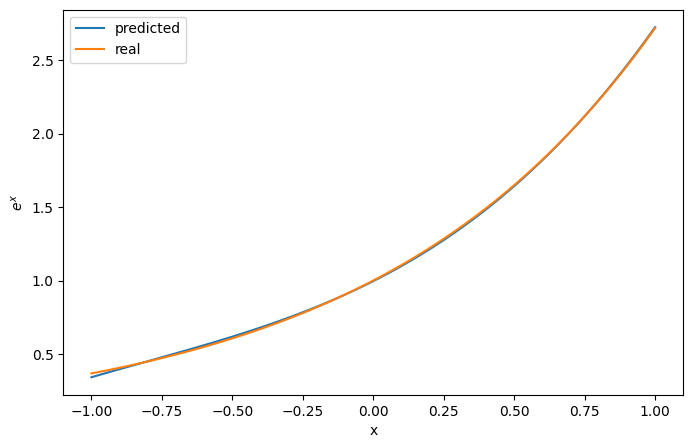

In [2]:
r"""
PyTorch: Tensors and autograd
-------------------------------

A third order polynomial, trained to predict :math:`y=e^x` from :math:`-1`
to :math:`1` by minimizing squared Euclidean distance.

This implementation computes the forward pass using operations on PyTorch
Tensors, and uses PyTorch autograd to compute gradients.


A PyTorch Tensor represents a node in a computational graph. If ``x`` is a
Tensor that has ``x.requires_grad=True`` then ``x.grad`` is another Tensor
holding the gradient of ``x`` with respect to some scalar value.
"""
import torch

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-1, 1, 2000, dtype=dtype)
y = torch.exp(x) # A Taylor expansion would be 1 + x + (1/2) x**2 + (1/3!) x**3 + ...

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

learning_rate = 1e-5
for t in range(5000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_pred - y).pow(2).sum()

    # Calculare initial loss, so we can report loss relative to it
    if t==0:
        initial_loss=loss.item()

    if t % 100 == 99:
        print(f'Iteration t = {t:4d}  loss(t)/loss(0) = {round(loss.item()/initial_loss, 6):10.6f}  a = {a.item():10.6f}  b = {b.item():10.6f}  c = {c.item():10.6f}  d = {d.item():10.6f}')

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')


import matplotlib.pyplot as plt

def fit(x):
    return a.item() + b.item() * x + c.item() * x**2 + d.item() * x**3

y_pred = [fit(_x) for _x in x]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y_pred, label="predicted")
ax.plot(x, y, label="real")
ax.set_xlabel("x")
ax.set_ylabel("$e^x$")
ax.legend()
plt.show()

In [28]:
import torch

x = torch.arange(10*100*64).reshape(10, 100, 64)
# print(x)
y = x.view(10, 100, 8, 8)
print(y.shape)
print(y.is_contiguous())
y = y.transpose(1, 2)
print(y.is_contiguous())
y = y.transpose(2, 1)
print(y.is_contiguous())

torch.Size([10, 100, 8, 8])
True
False
True


In [13]:
y.fold

AttributeError: 'Tensor' object has no attribute 'fold'

In [25]:
base = torch.tensor([[0, 1],[2, 3]])
print(base.is_contiguous())
t = base.transpose(0, 1)  # `t` is a view of `base`. No data movement happened here.
print(t.is_contiguous())
tt = t.transpose(0, 1)
print(tt.is_contiguous())
# c = t.contiguous()

True
False
True


In [21]:
base.transpose(0, 1).transpose(1, 0).is_contiguous()

True